**CAPSTONE PROJECT**

Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Data

This dataset is from NYC Open Data. It was provided by the Office of the Comptroller and covers the Claims Report Underlying Settlements and Claims Filed data. The data lists the claims filed against the City of New York.

I chose to analyze this dataset because of my experience working with claims in my agency. Disputes with contractors may escalate to the Office of the Comptroller for determination, and community members are also directed to file claims there. This made me interested in understanding the Comptroller’s claims data.

The goal of this analysis is to understand the most common types of claims that the Comptroller receives and to identify which types of claims the City spends the most money on. Also I would like to know the borough with the most claims.

In [ ]:
df= pd.read_csv("https://data.cityofnewyork.us/resource/ex6k-ym48.csv?$limit=100000")

I'm using the methods df.describe(), df.head(), df.columns and df.info() to see the data

In [ ]:
df.describe()

,fiscal_year_fy_,disposition_amount
count,100000.000000,3.220000e+04
mean,2021.852870,8.240821e+04
std,0.968314,4.912513e+05
min,2020.000000,8.100000e-01
25%,2021.000000,3.685985e+03
50%,2022.000000,1.000000e+04
75%,2023.000000,3.250000e+04
max,2023.000000,3.630000e+07


In [ ]:
df.head()

,fiscal_year_fy_,claim,borough,occurrence_date,filed_date,claim_type,disposition_date,disposition_amount,agency,claim_action
0,2023,2021PD031716,BRONX,2021-10-29T00:00:00.000,2021-10-30T00:00:00.000,City Personnel,2023-01-25T00:00:00.000,2500.00,Department of Parks & Recration,SETTLED
1,2023,2022PI028154,BRONX,2022-07-20T00:00:00.000,2022-10-04T00:00:00.000,Correction Facility,2023-04-11T00:00:00.000,3000.00,Department of Correction,SETTLED
2,2023,2022PD022588,BRONX,2022-07-03T00:00:00.000,2022-08-02T00:00:00.000,Motor Vehicle,2023-05-24T00:00:00.000,879.47,Police Department,SETTLED
3,2023,2020PI016587,MANHATTAN (NEW YORK),2020-05-08T00:00:00.000,2020-06-29T00:00:00.000,Sidewalk,2023-02-28T00:00:00.000,15000.00,Department of Transportation,SETTLED
4,2023,2021PI006641,BRONX,2020-04-15T00:00:00.000,2021-03-11T19:22:07.000,Police Action,2022-10-04T00:00:00.000,12500.00,Police Department,SETTLED


In [ ]:
df.columns

Index(['fiscal_year_fy_', 'claim', 'borough', 'occurrence_date', 'filed_date',
       'claim_type', 'disposition_date', 'disposition_amount', 'agency',
       'claim_action'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   fiscal_year_fy_     100000 non-null  int64  
 1   claim               100000 non-null  object 
 2   borough             92663 non-null   object 
 3   occurrence_date     96782 non-null   object 
 4   filed_date          100000 non-null  object 
 5   claim_type          100000 non-null  object 
 6   disposition_date    32200 non-null   object 
 7   disposition_amount  32200 non-null   float64
 8   agency              100000 non-null  object 
 9   claim_action        100000 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 7.6+ MB


In [ ]:
df.shape

(100000, 10)

I'm using Unique to check the unique types of claims and the boroughs included in the data.

In [ ]:
df["claim_type"].unique()

array(['City Personnel', 'Correction Facility', 'Motor Vehicle',
       'Sidewalk', 'Police Action', 'Civil Rights', 'Roadway', 'School',
       'Parks & Recreation', 'Sewer Overflow', 'Traffic Control Device',
       'City Property', 'Uniformed Services Employee', 'Other',
       'Medical Malpractice', 'Water Main', 'Health Facility'],
      dtype=object)

In [ ]:
df["claim_type"].nunique()

17

In [ ]:
df["borough"].unique()

array(['BRONX', 'MANHATTAN (NEW YORK)', 'QUEENS', nan,
       'STATEN ISLAND (RICHMOND)', 'BROOKLYN (KINGS)', 'NASSAU',
       'SCHOHARIE', 'GREENE', 'WESTCHESTER', 'NEW JERSEY', 'ALBANY',
       'UNKNOWN', 'DUTCHESS', 'OTHER', 'SUFFOLK', 'ROCKLAND', 'ERIE',
       'PUTNAM', 'ORANGE', 'SCHENECTADY', 'ULSTER', 'SULLIVAN COUNTY'],
      dtype=object)

Data Cleaning

In [ ]:
null_values = ["?", "None", "NONE", "null", "NULL", "", "NaN", "nan", "(null)"]

df_clean = df.dropna(subset=["claim_type", "borough"])

In [ ]:
df_clean.shape

(92663, 10)

The original data shape was 100,000 rows and now is 92,663 rows.

Most common claim types:

In [ ]:
print(df_clean["claim_type"].value_counts().head(5))

claim_type
Police Action          19731
Motor Vehicle          18366
Correction Facility    14060
Sidewalk                8636
Roadway                 6436
Name: count, dtype: int64


Highest average amounts by claim types


In [ ]:
df_top_claims= df_clean.groupby("claim_type")["disposition_amount"].mean().sort_values(ascending=False)

In [ ]:
df_top_claims.head()

,disposition_amount
claim_type,
Medical Malpractice,692893.667568
Traffic Control Device,325909.090909
Uniformed Services Employee,293439.839572
Civil Rights,271794.614729
City Property,265903.888776


Total claim amounts by claim type

In [ ]:
df_top_sumclaims= df_clean.groupby("claim_type")["disposition_amount"].sum().sort_values(ascending=False)

In [ ]:
df_top_sumclaims.head()

,disposition_amount
claim_type,
Motor Vehicle,6.014016e+08
Civil Rights,3.661073e+08
Police Action,3.345635e+08
Sidewalk,2.306954e+08
Medical Malpractice,2.279620e+08


Borough with the most claims

In [ ]:
borough_counts = df_clean['borough'].value_counts()
print(borough_counts.head(5))

borough
BRONX                       30376
BROOKLYN (KINGS)            23093
QUEENS                      17973
MANHATTAN (NEW YORK)        16045
STATEN ISLAND (RICHMOND)     4503
Name: count, dtype: int64


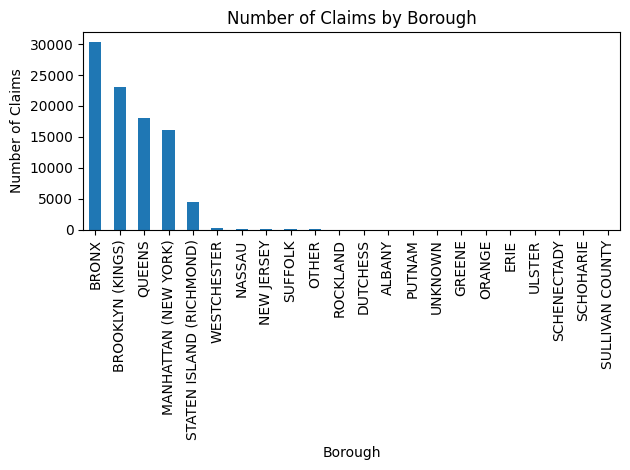

In [ ]:
plt.figure()
borough_counts.plot(kind='bar')
plt.title('Number of Claims by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Claims')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

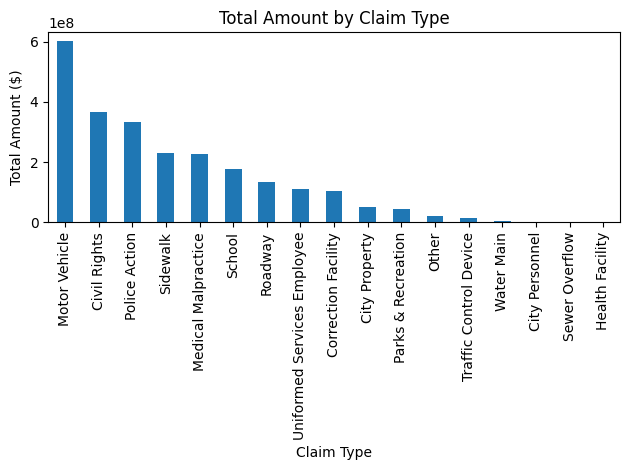

In [ ]:
plt.figure()
df_top_sumclaims.plot(kind='bar')
plt.title('Total Amount by Claim Type')
plt.xlabel('Claim Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

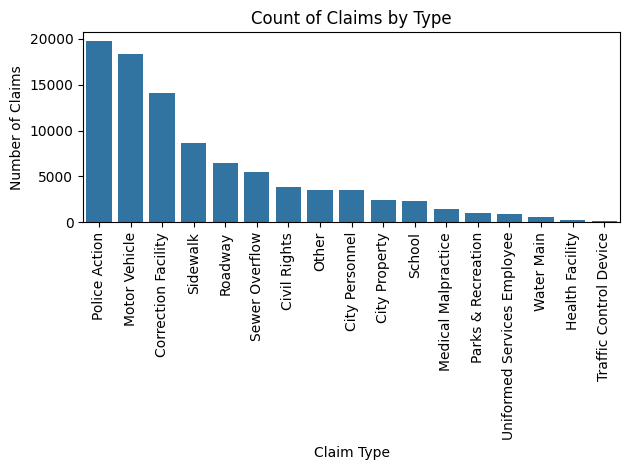

In [ ]:
plt.figure()
sns.countplot(data=df_clean, x='claim_type', order=df_clean['claim_type'].value_counts().index)
plt.title('Count of Claims by Type')
plt.xlabel('Claim Type')
plt.ylabel('Number of Claims')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

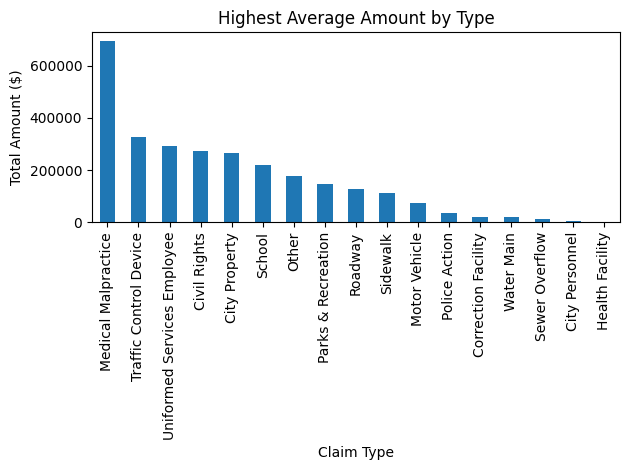

In [ ]:
plt.figure()
df_top_claims.plot(kind='bar')
plt.title('Highest Average Amount by Type')
plt.xlabel('Claim Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Conclusion

This analysis looked at the most common claim types, the average cost of claims, the total amount spent, and the distribution by borough.

The results show that Police Action claims are the most common, as seen in the graph of claim counts. However, they are not the most expensive. Medical Malpractice claims have the highest average cost per claim.

In terms of total spending, Motor Vehicle claims have the highest total amount paid, meaning they represent the greatest overall financial impact to the City.

The borough analysis shows that the Bronx has the highest number of claims, indicating that more claims are reported there compared to other boroughs.

Overall, the graphs show that the most frequent claims, the most expensive claims on average, and the claims with the highest total cost are not the same.